# Contexte
Une entreprise possède plusieurs bâtiments équipés de capteurs IoT.
Chaque capteur collecte régulièrement des informations sur la température, l'humidité, la pression,
la consommation énergétique, le bâtiment, la date et l'heure de la mesure.
Chaque mesure possède également un état (OK, ALERTE et ERREUR).
L'objectif de l'atelier est de construire un modèle capable de prédire automatiquement l'état d'un
capteur à partir de ses mesures.
L'atelier suivra le workflow classique du Machine Learning :
Dataset → Chargement → Exploration → Nettoyage → X / y → Train / Test → Prétraitement →
Modèle → fit()→ predict()→ Évaluation → Sauvegarde → Chargement → Réutilisation

In [1]:
# ! pip install seaborn matplotlib pandas scikit-learn joblib

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib
import pickle



In [3]:
df = pd.read_csv("../data/mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


# Partie 1 – Gestion des doublons

## 1) vérifier l’existence de doublons dans df

In [4]:
nb_doublons = df.duplicated().sum()
print(f"Nombre de doublons : {nb_doublons}")

Nombre de doublons : 5


## 2) le cas échéant, supprimer les doublons puis vérifier la suppression

In [5]:
# 2) Suppression des doublons (le cas échéant) puis vérification
if nb_doublons > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"Nombre de doublons après suppression : {df.duplicated().sum()}")
print("Nouvelles dimensions :", df.shape)


Nombre de doublons après suppression : 0
Nouvelles dimensions : (600, 9)


# Partie 2 – Sélection de y (cible) et X (caractéristiques)

## 1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite", "pression" et "consommation" comme caractéristiques ou variables explicatives

In [6]:
print("Valeurs manquantes de la cible 'etat' :", df["etat"].isna().sum())
df = df.dropna(subset=["etat"]).reset_index(drop=True)
print("Dimensions après retrait des cibles manquantes :", df.shape)


Valeurs manquantes de la cible 'etat' : 4
Dimensions après retrait des cibles manquantes : (596, 9)


In [7]:
features = ["temperature", "humidite", "pression", "consommation"]
target = "etat"

X = df[features]
y = df[target]

## 2) Afficher les cinq premières lignes de X et de y

In [8]:
X.head()

,temperature,humidite,pression,consommation
0,25.46,58.06,1008.95,287.28
1,24.00,79.73,993.39,116.20
2,25.82,54.47,1010.32,288.50
3,28.23,69.39,1019.62,136.65
4,20.58,53.80,1016.58,182.62


In [9]:
y.head()

0    OK
1    OK
2    OK
3    OK
4    OK
Name: etat, dtype: str

## 3) Quel est le type du problème de machine learning ?

Il s'agit d'un problème d'**apprentissage supervisé de classification multi-classes** : la cible
etat est une variable catégorielle à trois modalités (OK, ALERTE, ERREUR), et le modèle
doit apprendre, à partir d'exemples déjà étiquetés, à prédire la bonne classe pour de nouvelles
observations.

# Partie 3 – Découpage Train/Test

Divisons X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test).
Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du
découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que
dans les données d'origine.

In [10]:
# 20% pour le test, reproductibilité (random_state) et conservation des proportions
# de classes (stratify=y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
print("\nProportions des classes (données d'origine) :")
print(y.value_counts(normalize=True))
print("\nProportions des classes (train) :")
print(y_train.value_counts(normalize=True))
print("\nProportions des classes (test) :")
print(y_test.value_counts(normalize=True))

X_train : (476, 4) | X_test : (120, 4)

Proportions des classes (données d'origine) :
etat
OK        0.942953
ALERTE    0.048658
ERREUR    0.008389
Name: proportion, dtype: float64

Proportions des classes (train) :
etat
OK        0.943277
ALERTE    0.048319
ERREUR    0.008403
Name: proportion, dtype: float64

Proportions des classes (test) :
etat
OK        0.941667
ALERTE    0.050000
ERREUR    0.008333
Name: proportion, dtype: float64


# Partie 4 – Gestion des valeurs manquantes

## 1) Vérifier l’existence de valeurs manquantes

In [11]:
print("Valeurs manquantes X_train :")
print(X_train.isna().sum())
print("\nValeurs manquantes X_test :")
print(X_test.isna().sum())

Valeurs manquantes X_train :
temperature     5
humidite        4
pression        5
consommation    3
dtype: int64

Valeurs manquantes X_test :
temperature     1
humidite        1
pression        0
consommation    2
dtype: int64


## 2) Sélectionner SimpleImputer avec la médiane

In [13]:
imputer = SimpleImputer(strategy="median")

## 3) Qu’est ce qui justifie le choix de la médiane ?

La médiane est plus **robuste aux valeurs extrêmes (outliers)** que la moyenne : une mesure
aberrante de température, pression ou consommation ne fait pas basculer la valeur de remplacement
comme le ferait la moyenne. Les capteurs IoT peuvent produire des mesures bruitées ou extrêmes lors
de pannes, ce qui justifie ce choix pour des variables numériques continues.
D’ailleurs, quand on a visualisé les données, on a observé des valeurs extrêmes. 


## 4) Trouver les paramètres (médianes) de l’imputeur sur X_train

In [14]:
imputer.fit(X_train)
print("Médianes apprises :", dict(zip(features, imputer.statistics_)))

Médianes apprises : {'temperature': np.float64(24.9), 'humidite': np.float64(65.38), 'pression': np.float64(1012.3), 'consommation': np.float64(206.59)}


## 5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test

In [15]:
X_train_imputed = pd.DataFrame(imputer.transform(X_train), columns=features, index=X_train.index)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=features, index=X_test.index)

print("Valeurs manquantes restantes (train) :", X_train_imputed.isna().sum().sum())
print("Valeurs manquantes restantes (test) :", X_test_imputed.isna().sum().sum())
X_train_imputed.head()

Valeurs manquantes restantes (train) : 0
Valeurs manquantes restantes (test) : 0


,temperature,humidite,pression,consommation
97,26.14,84.97,1003.59,142.31
473,22.27,44.03,1005.85,138.16
192,28.13,75.78,1003.24,242.62
246,25.51,68.57,1024.71,96.51
127,33.60,79.80,1021.96,212.55


# Partie 5 – Mise à l'échelle

## 1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation

In [18]:
scaler = StandardScaler()

## 2) Qu’est ce qui justifie la standardisation ?

Les variables (température, humidité, pression, consommation) sont exprimées dans des unités et
des échelles très différentes (ex. pression ~1000 hPa contre température ~25 °C). Le modèle KNN
utilisé ensuite repose sur des **distances euclidiennes** : sans standardisation, la variable ayant
les plus grandes valeurs (la pression) dominerait artificiellement le calcul de distance. La
standardisation (moyenne 0, écart-type 1) place toutes les variables sur un pied d'égalité.

## 3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed

In [19]:
scaler.fit(X_train_imputed)
print("Moyennes apprises :", dict(zip(features, scaler.mean_)))
print("Écarts-types appris :", dict(zip(features, np.sqrt(scaler.var_))))


Moyennes apprises : {'temperature': np.float64(24.963739495798322), 'humidite': np.float64(64.85044117647058), 'pression': np.float64(1012.0762184873951), 'consommation': np.float64(210.15394957983193)}
Écarts-types appris : {'temperature': np.float64(4.1930397869358025), 'humidite': np.float64(10.16279172913295), 'pression': np.float64(10.99418360293844), 'consommation': np.float64(73.4209232247452)}


## 4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et X_test_imputed

In [20]:
X_train_scaled = pd.DataFrame(scaler.transform(X_train_imputed), columns=features, index=X_train_imputed.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imputed), columns=features, index=X_test_imputed.index)

X_train_scaled.describe()

,temperature,humidite,pression,consommation
count,4.760000e+02,4.760000e+02,4.760000e+02,4.760000e+02
mean,-6.120221e-16,5.970947e-16,-9.911773e-15,3.358658e-17
std,1.001052e+00,1.001052e+00,1.001052e+00,1.001052e+00
min,-1.036569e+01,-2.855558e+00,-1.474200e+01,-2.615521e+00
25%,-5.500161e-01,-6.637390e-01,-4.869592e-01,-6.806840e-01
50%,-1.520126e-02,5.210761e-02,2.035454e-02,-4.854133e-02
75%,5.583683e-01,6.626682e-01,5.203917e-01,6.131229e-01
max,8.045776e+00,2.779705e+00,2.397066e+00,9.055267e+00


# Partie 6 – Entrainement et prédiction d’un modèle

## 1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en compte

In [22]:
model = KNeighborsClassifier(n_neighbors=5)

## 2) Entrainer le modèle

In [23]:
model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test

In [24]:
y_pred = model.predict(X_test_scaled)

## 4) Afficher quelques prédictions

In [25]:
print("Premières prédictions :", y_pred[:10])

Premières prédictions : ['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK']


## 5) Comparer ces prédictions avec les vraies valeurs

In [26]:
comparaison = pd.DataFrame({
    "y_test (vraie valeur)": y_test.values,
    "y_pred (prédiction)": y_pred
}).reset_index(drop=True)
comparaison["correct"] = comparaison["y_test (vraie valeur)"] == comparaison["y_pred (prédiction)"]
comparaison.head(15)

,y_test (vraie valeur),y_pred (prédiction),correct
0,OK,OK,True
1,OK,OK,True
2,OK,OK,True
3,OK,OK,True
4,ALERTE,OK,False
5,OK,OK,True
6,OK,OK,True
7,OK,OK,True
8,OK,OK,True
9,OK,OK,True


# Partie 7 – Evaluation du modèle

## 1) Evaluer le modèle avec Accuracy puis afficher le résultat

In [28]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy : {acc:.4f}")

Accuracy : 0.9583


## 2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ?

Le jeu de données est **déséquilibré** : la classe `OK` représente la grande majorité des mesures,
tandis que `ALERTE` et `ERREUR` sont rares. Un modèle qui prédirait systématiquement `OK` obtiendrait
déjà une accuracy élevée, tout en étant totalement inutile pour détecter les cas critiques (alertes
et erreurs), qui sont précisément ceux qui nous intéressent le plus. Il faut donc compléter
l'accuracy par des métriques par classe (précision, rappel, F1-score) et par la matrice de confusion.


## 3) Déterminer, afficher et commenter la matrice de confusion

In [30]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"Vrai {l}" for l in labels], columns=[f"Prédit {l}" for l in labels])
cm_df


,Prédit ALERTE,Prédit ERREUR,Prédit OK
Vrai ALERTE,2,0,4
Vrai ERREUR,1,0,0
Vrai OK,0,0,113


**Commentaire :** la diagonale de la matrice concentre les prédictions correctes. Ici on constate que le modele predit 4 etat comme OK alors que ce sont des ALERTE et predit une valeur comme ALERTE alors que c'est une ERREUR


## 4) Visualiser cette matrice avec Seaborn

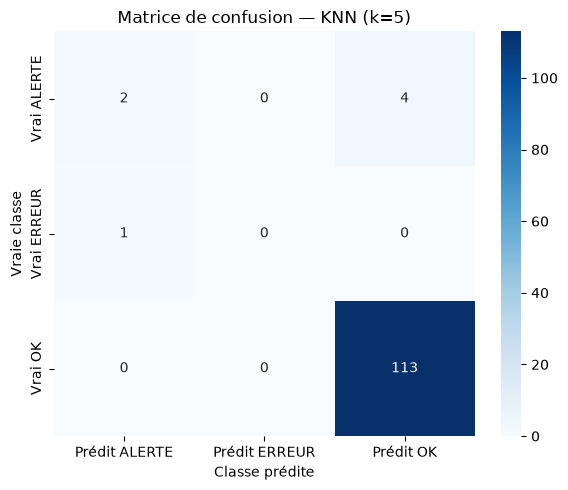

In [32]:
# 4) Visualisation de la matrice de confusion avec Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Matrice de confusion — KNN (k=5)")
plt.ylabel("Vraie classe")
plt.xlabel("Classe prédite")
plt.tight_layout()
plt.show()

## 5) Afficher et commenter le rapport de classificaton

In [34]:
report = classification_report(y_test, y_pred, labels=labels, zero_division=0)
print(report)

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



**Commentaire :** le rapport détaille, pour chaque classe, la précision (proportion de
prédictions correctes parmi les prédictions de cette classe), le rappel (proportion de cas réels de
cette classe correctement détectés) et le F1-score (moyenne harmonique des deux). Les classes
minoritaires (`ALERTE`, `ERREUR`) sont généralement plus difficiles à bien prédire, faute d'exemples
suffisants pour l'apprentissage.

## 6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision

### même question avec recall

### même question avec F1 score 

### même question avec accuracy

- **Precision** : à privilégier quand le **coût d'un faux positif** est élevé — par exemple si
  chaque `ALERTE` prédite déclenche une intervention technique coûteuse, on veut être sûr qu'une
  alerte prédite est une vraie alerte.
- **Recall (rappel)** : à privilégier quand le **coût d'un faux négatif** est élevé — ici, rater une
  vraie `ERREUR` ou `ALERTE` (la prédire comme `OK`) peut être dangereux, donc on préfère maximiser
  la détection même au prix de quelques fausses alertes.
- **F1-score** : à privilégier quand on veut un **compromis équilibré** entre precision et recall,
  notamment sur des classes déséquilibrées comme `ALERTE`/`ERREUR` ici.
- **Accuracy** : à privilégier uniquement quand les **classes sont équilibrées** et que toutes les
  erreurs ont un coût similaire — ce qui n'est pas le cas de ce jeu de données.

# Partie 8 – Sauvegarde du modèle

## 1) Sauvegarder le modèle avec Joblib pour avoir models/modele_capteurs.joblib

In [37]:
joblib.dump(model, "../models/modele_capteur.joblib")
print("Modèle sauvegardé : models/modele_capteur.joblib")

Modèle sauvegardé : models/modele_capteur.joblib


## 2) Sauvegarder le modèle avec Pickle pour avoir models/modele_capteurs.pkl

In [38]:
with open("../models/modele_capteur.pkl", "wb") as f:
    pickle.dump(model, f)
print("Modèle sauvegardé : models/modele_capteur.pkl")

Modèle sauvegardé : models/modele_capteur.pkl


# Partie 9 – Chargement du modèle

## 1) Charger le modèle

In [39]:
modele_charge = joblib.load("../models/modele_capteur.joblib")
modele_charge

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['ALERTE','ERREUR','OK']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 2) Faire une prédiction avec une nouvelle mesure

In [40]:
# Exemple d'une nouvelle mesure brute : température, humidité, pression, consommation
nouvelle_mesure = pd.DataFrame(
    [[26.5, 60.0, 1012.0, 210.0]],
    columns=features
)

# On applique le MÊME prétraitement que pour l'entraînement (imputation puis mise à l'échelle)
nouvelle_mesure_imputed = pd.DataFrame(imputer.transform(nouvelle_mesure), columns=features)
nouvelle_mesure_scaled = pd.DataFrame(scaler.transform(nouvelle_mesure_imputed), columns=features)

prediction = modele_charge.predict(nouvelle_mesure_scaled)
print(f"État prédit pour la nouvelle mesure : {prediction[0]}")

État prédit pour la nouvelle mesure : OK
